<a href="https://colab.research.google.com/github/clessiokalieldossantos-lab/scadriano-lia1_2026_1/blob/main/Projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install Kaggle

In [ ]:
from tensorflow.keras.datasets import reuters

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)

!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d nltkdata/reuters

Dataset URL: https://www.kaggle.com/datasets/nltkdata/reuters
License(s): other
100% 12.8M/12.8M [00:00<00:00, 61.2MB/s]



In [ ]:
!unzip reuters.zip

A saída de streaming foi truncada nas últimas 5000 linhas.
  inflating: reuters/reuters/training/2231  
  inflating: reuters/reuters/training/2232  
  inflating: reuters/reuters/training/2234  
  inflating: reuters/reuters/training/2236  
  inflating: reuters/reuters/training/2237  
  inflating: reuters/reuters/training/2238  
  inflating: reuters/reuters/training/2239  
  inflating: reuters/reuters/training/2240  
  inflating: reuters/reuters/training/2244  
  inflating: reuters/reuters/training/2246  
  inflating: reuters/reuters/training/2247  
  inflating: reuters/reuters/training/2249  
  inflating: reuters/reuters/training/225  
  inflating: reuters/reuters/training/2251  
  inflating: reuters/reuters/training/2252  
  inflating: reuters/reuters/training/2253  
  inflating: reuters/reuters/training/2257  
  inflating: reuters/reuters/training/2259  
  inflating: reuters/reuters/training/2260  
  inflating: reuters/reuters/training/2264  
  inflating: reuters/reuters/training/2265

## Carregando o DataSet

In [ ]:
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences

num_words = 10000

(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=num_words)

x_train = pad_sequences(x_train, maxlen=200)
x_test = pad_sequences(x_test, maxlen=200)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Criando o Modelo

In [ ]:
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Embedding(input_dim=10000, output_dim=64, input_length=200),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')  # 46 categorias
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(x_train, y_train, epochs=5, batch_size=512, validation_split=0.2)

Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.3399 - loss: 3.1307 - val_accuracy: 0.3645 - val_loss: 2.6723
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.3763 - loss: 2.5893 - val_accuracy: 0.3723 - val_loss: 2.4400
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.3807 - loss: 2.4117 - val_accuracy: 0.3723 - val_loss: 2.3320
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.3976 - loss: 2.3112 - val_accuracy: 0.4391 - val_loss: 2.2503
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.4213 - loss: 2.2217 - val_accuracy: 0.4407 - val_loss: 2.1672


In [ ]:
loss, acc = model.evaluate(x_test, y_test)
print(f"Acurácia: {acc*100:.2f}%")

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4479 - loss: 2.1937
Acurácia: 44.79%


In [ ]:
print("Treinando o modelo...")

Treinando o modelo...


In [ ]:
print("Avaliando o modelo...")

Avaliando o modelo...


Epoch 1/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4924 - loss: 1.9995 - val_accuracy: 0.5364 - val_loss: 1.8455
Epoch 2/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5840 - loss: 1.7285 - val_accuracy: 0.6171 - val_loss: 1.6170
Epoch 3/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6476 - loss: 1.5228 - val_accuracy: 0.6739 - val_loss: 1.4659
Epoch 4/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6809 - loss: 1.3609 - val_accuracy: 0.6856 - val_loss: 1.3482
Epoch 5/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6994 - loss: 1.2345 - val_accuracy: 0.6923 - val_loss: 1.2618


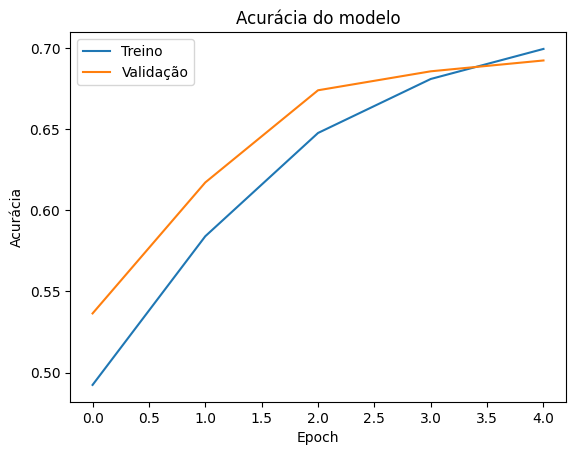

In [ ]:
import matplotlib.pyplot as plt

history = model.fit(x_train, y_train, epochs=5, validation_split=0.2)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Acurácia do modelo')
plt.xlabel('Epoch')
plt.ylabel('Acurácia')
plt.legend(['Treino', 'Validação'])
plt.show()

In [ ]:
import numpy as np

sample = x_test[0]
prediction = model.predict(np.array([sample]))

print("Classe prevista:", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Classe prevista: 3


In [ ]:
for i in range(5):
    sample = x_test[i]
    prediction = model.predict(np.array([sample]))
    predicted_class = np.argmax(prediction)

    print(f"Notícia {i+1}")
    print("Prevista:", predicted_class)
    print("Real:", y_test[i])
    print("-" * 30)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Notícia 1
Prevista: 3
Real: 3
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Notícia 2
Prevista: 11
Real: 10
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Notícia 3
Prevista: 1
Real: 1
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Notícia 4
Prevista: 4
Real: 4
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Notícia 5
Prevista: 16
Real: 4
------------------------------


In [ ]:
print("Probabilidades:", prediction)

Probabilidades: [[0.01733058 0.07064571 0.02632332 0.00825939 0.1377745  0.0038384
  0.0107879  0.00177461 0.01502964 0.02049869 0.04234757 0.06353705
  0.0052852  0.1516982  0.00426214 0.00791895 0.18933953 0.01056898
  0.00434345 0.02726358 0.01297391 0.00718203 0.00127679 0.01193025
  0.01122039 0.02483001 0.00901783 0.00508835 0.01728247 0.0018804
  0.00257283 0.0083697  0.01509537 0.00271602 0.00372597 0.00215391
  0.00494948 0.00292608 0.00222912 0.00683227 0.00979248 0.00829605
  0.00312509 0.00138407 0.0011047  0.00321688]]


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


<Figure size 1000x800 with 0 Axes>

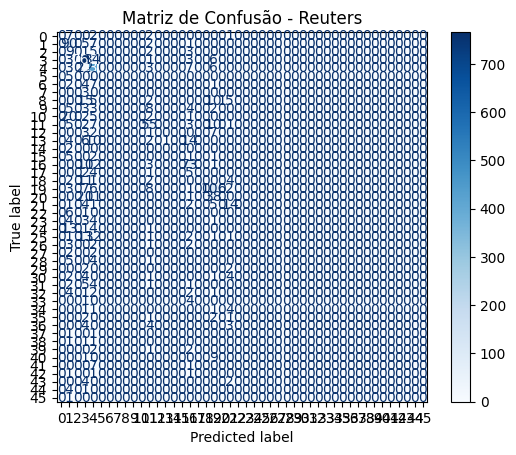

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Fazer previsões no conjunto de teste
y_pred_probs = model.predict(x_test)

# Converter probabilidades em classes
y_pred = np.argmax(y_pred_probs, axis=1)

# Criar matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Plotar
plt.figure(figsize=(10,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão - Reuters")
plt.show()